# Assignment

**Task 1:** Split the MNIST dataset into training and test sets (60k + 10k). Train a Random Forest classifier and measure the training time. Compute the accuracy on the test set.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np

from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import time

In [3]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1, cache=True)

X = mnist["data"]
y = mnist["target"].astype(np.uint8)

C:\Users\User\venv\lib\site-packages\sklearn\datasets\_openml.py:1022: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


## Random Forest classifier

#### Spliting the data

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=10000/70000, random_state=42)

#### Training & Time measurement

In [7]:
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

start_time = time.time()
rf_clf.fit(X_train, y_train)
training_time = time.time() - start_time

#### Prediction & Results 🎉

In [8]:
y_pred = rf_clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Training time: {training_time:.2f} seconds")
print(f"Accuracy: {accuracy:.2%}")

Training time: 72.69 seconds
Accuracy: 96.74%


**Task 2:** Apply PCA with 95% explained variance. Repeat the training. Compare the training time and accuracy with the previous exercise.

Keeping 95% of the variance ensures a good balance between reducing dimensions and maintaining the accuracy of the data representation. It avoids retaining unnecessary features that contribute little to the overall variance, making the model faster and more efficient.

In [9]:
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"Сomponents after PCA: {pca.n_components_}")

Сomponents after PCA: 154


## Random Forest classifier with PCA-transformed data

#### Training & Time measurement

In [10]:
rf_clf_pca = RandomForestClassifier(n_estimators=100, random_state=42)

start_time = time.time()
rf_clf_pca.fit(X_train_pca, y_train)
training_time_pca = time.time() - start_time

#### Prediction & Results 🎉

In [11]:
y_pred_pca = rf_clf_pca.predict(X_test_pca)
accuracy_pca = accuracy_score(y_test, y_pred_pca)

print(f"Training time with PCA: {training_time_pca:.2f} seconds")
print(f"Accuracy with PCA: {accuracy_pca:.2%}")

Training time with PCA: 300.20 seconds
Accuracy with PCA: 94.69%


## Сomparison graph

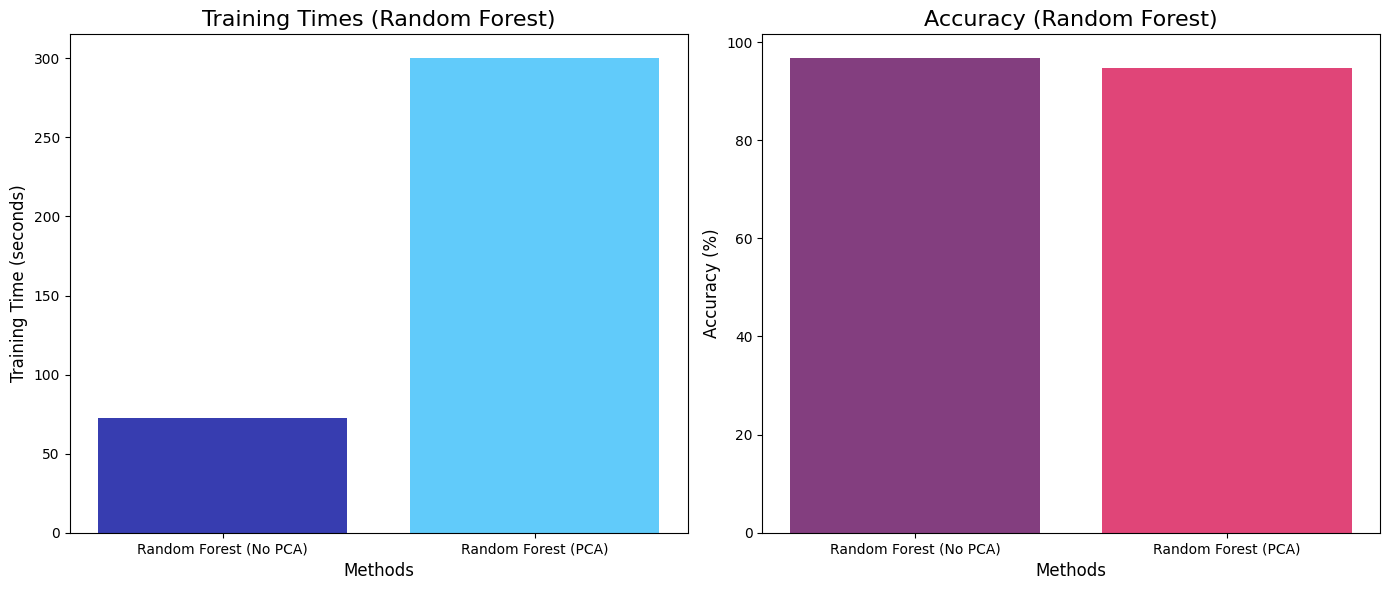

In [29]:
methods_rf = ['Random Forest (No PCA)', 'Random Forest (PCA)']
training_times_rf = [72.69, 300.20]
accuracies_rf = [96.74, 94.69]

colors_training = ['#050C9C', '#3ABEF9']
colors_accuracy = ['#640D5F', '#D91656']

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].bar(methods_rf, training_times_rf, color=colors_training, alpha=0.8)
ax[0].set_title('Training Times (Random Forest)', fontsize=16)
ax[0].set_ylabel('Training Time (seconds)', fontsize=12)
ax[0].set_xlabel('Methods', fontsize=12)

ax[1].bar(methods_rf, accuracies_rf, color=colors_accuracy, alpha=0.8)
ax[1].set_title('Accuracy (Random Forest)', fontsize=16)
ax[1].set_ylabel('Accuracy (%)', fontsize=12)
ax[1].set_xlabel('Methods', fontsize=12)

plt.tight_layout()
plt.show()

**Task 3:** Repeat the same steps with logistic regression. Make conclusions.

## Logistic Regression

#### Training & Time measurement

In [14]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)

start_time = time.time()
log_reg.fit(X_train, y_train) 
training_time = time.time() - start_time

C:\Users\User\venv\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#### Prediction & Results 🎉

In [15]:
y_pred = log_reg.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Training time: {training_time:.2f} seconds")
print(f"Accuracy: {accuracy:.2%}")

Training time: 283.49 seconds
Accuracy: 91.75%


## Logistic Regression with PCA-transformed data

#### Training & Time measurement

In [16]:
log_reg_pca = LogisticRegression(max_iter=1000, random_state=42)

start_time = time.time()
log_reg_pca.fit(X_train_pca, y_train) 
training_time_pca = time.time() - start_time

C:\Users\User\venv\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#### Prediction & Results 🎉

In [17]:
y_pred_pca = log_reg_pca.predict(X_test_pca)
accuracy_pca = accuracy_score(y_test, y_pred_pca)

print(f"Training time with PCA: {training_time_pca:.2f} seconds")
print(f"Accuracy with PCA: {accuracy_pca:.2%}")

Training time with PCA: 76.86 seconds
Accuracy with PCA: 91.69%


## Сomparison graph

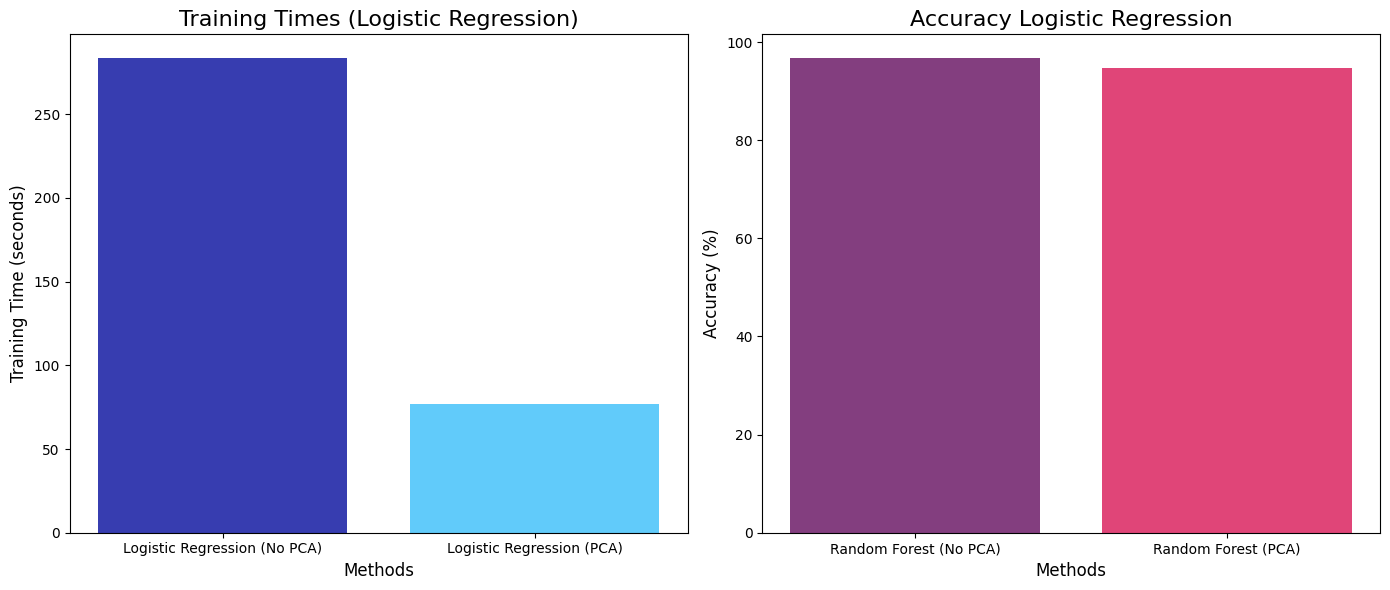

In [30]:
methods_lr = ['Logistic Regression (No PCA)', 'Logistic Regression (PCA)']
training_times_lr = [283.49, 76.86]
accuracies_ln = [91.75, 91.69]

colors_training = ['#050C9C', '#3ABEF9']
colors_accuracy = ['#640D5F', '#D91656']

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].bar(methods_lr, training_times_lr, color=colors_training, alpha=0.8)
ax[0].set_title('Training Times (Logistic Regression)', fontsize=16)
ax[0].set_ylabel('Training Time (seconds)', fontsize=12)
ax[0].set_xlabel('Methods', fontsize=12)

ax[1].bar(methods_rf, accuracies_rf, color=colors_accuracy, alpha=0.8)
ax[1].set_title('Accuracy Logistic Regression', fontsize=16)
ax[1].set_ylabel('Accuracy (%)', fontsize=12)
ax[1].set_xlabel('Methods', fontsize=12)

plt.tight_layout()
plt.show()

## Conclusions:

- **Logistic Regression:**
The results show that PCA greatly improves the training efficiency of Logistic Regression. Without PCA, the high dimensionality of the MNIST dataset makes training Logistic Regression much slower. However, after using PCA to reduce the number of features, the training time is significantly shorter, while the accuracy stays nearly the same. This shows that PCA is very effective in making Logistic Regression faster and more efficient, especially for datasets with many features.
- **Random Forest classifier:**
In contrast, the effect of PCA on Random Forest is quite different. Instead of reducing the training time, PCA actually increases it. This is likely because Random Forest inherently handles high-dimensional data well and does not rely on dimensionality reduction for efficiency. The additional preprocessing step introduced by PCA adds computational overhead, leading to a longer training time. Despite this, the accuracy of Random Forest remains relatively high, with only a slight decrease after PCA, indicating that the transformation does not significantly compromise the quality of the model.

## Thanks for reading! 🎀